# **Feature Selection Methods and Clinical Insights**

This notebook explores **feature selection** — the process of identifying which clinical features actually matter for predicting heart failure mortality, rather than using all 11 features blindly.

With only 299 patients and 11 features, some features are irrelevant or redundant. Including them can hurt model performance by introducing noise. We compare four methods to find the most informative subset:

- **Lasso** — penalizes model coefficients during training, shrinking unimportant ones to exactly zero
- **Elastic Net** — combines Lasso and Ridge for more stable selection, especially when features are correlated
- **MRMR** — a filter method that picks features with high relevance to the target and low redundancy with each other
- **Random Forest Importance** — ranks features by how much they reduce impurity across all trees

We then test whether using only the top selected features matches or outperforms using all 11 — and conclude with **clinical insights**: connecting the most important features back to medical literature to validate what the data is telling us.


In [ ]:
import numpy as np 
import pandas as pd 
from sklearn.model_selection import train_test_split

df = pd.read_csv('./heart_failure_clinical_records_dataset.csv')
df.drop(columns=['time'],inplace=True) # again drop the time column which is not one of the informative features 
df_features = df.iloc[:,:-1]
df_target = df['DEATH_EVENT']

X = df_features
y = df_target

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3,stratify=y,random_state=42)

print('X train shape: ',X_train.shape)
print('y train shape: ',y_train.shape)
print('X test shape: ',X_test.shape)
print('y test shape: ',y_test.shape)
print('y train: ',y_train.value_counts(normalize=True))
print('y test: ',y_test.value_counts(normalize=True))

feature_names = X.columns
feature_names

X train shape:  (209, 11)
y train shape:  (209,)
X test shape:  (90, 11)
y test shape:  (90,)
y train:  DEATH_EVENT
0    0.679426
1    0.320574
Name: proportion, dtype: float64
y test:  DEATH_EVENT
0    0.677778
1    0.322222
Name: proportion, dtype: float64


Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking'],
      dtype='object')

## Why normalize before Lasso/Elastic Net?

Lasso and Elastic Net use coefficient magnitudes to decide which features to drop. If features are on different scales (e.g., `platelets` ≈ 200,000 vs `age` ≈ 60), large-scale features will dominate unfairly.

`StandardScaler` transforms each feature to **mean = 0, std = 1**, so all features compete on equal footing.

**Rule:** Always fit the scaler on training data only (`fit_transform`), then apply to test data (`transform`). Fitting on test data would leak information.

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Why Feature Selection?

With 11 features and only 299 patients, some features are:
- **Irrelevant** — no real relationship with death (e.g., `sex`, `smoking` in this dataset)
- **Redundant** — highly correlated with another feature (adds noise, not information)

**Benefits of removing these features:**
- Reduces overfitting (model learns noise from irrelevant features)
- Faster training and inference
- More interpretable models

Compare three types of feature selection methods:

| Type | Method | How it selects |
|------|--------|----------------|
| **Embedded** | Lasso | Penalizes coefficients during model training |
| **Embedded** | Elastic Net | Like Lasso but with added Ridge stability |
| **Filter** | MRMR | Statistical score — relevance minus redundancy |
| **Embedded** | Random Forest | Feature importance from tree splits |

## (1) Lasso Feature Selection

**How it works:**

Lasso (Least Absolute Shrinkage and Selection Operator) fits a linear model with an L1 penalty:

$$\text{Loss} = \text{MSE} + \alpha \sum |\beta_i|$$

The penalty pushes small coefficients **exactly to zero**, effectively removing those features.

- **α (alpha)** controls the strength of the penalty — larger α = more features dropped
- `LassoCV` automatically finds the best α using 5-fold cross-validation

**Why it works for feature selection:**

Unlike Ridge (L2 penalty, which shrinks but never zeros), L1 creates **sparse solutions** — perfect for identifying which features to keep.

**Two thresholds below:**
- `B2 != 0` — any feature Lasso decided to keep at all
- `abs(B2) >= 0.02` — only features with meaningful coefficient size (stricter)

In [5]:
from sklearn import linear_model
model = linear_model.LassoCV(cv=5)
lasso_regression = model.fit(X_train,y_train)
B2 = lasso_regression.coef_
B2

array([ 0.0409842 ,  0.0155569 ,  0.0435928 ,  0.01277368, -0.10970532,
        0.01432047, -0.        ,  0.12604567, -0.01690006,  0.        ,
        0.        ])

In [6]:
selected_features = feature_names[B2 != 0]
selected_features
# selected_features = X.columns[abs(B2) >= 0.03]

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'serum_creatinine',
       'serum_sodium'],
      dtype='object')

In [7]:
selected_features = feature_names[abs(B2) >= 0.02]
selected_features

Index(['age', 'creatinine_phosphokinase', 'ejection_fraction',
       'serum_creatinine'],
      dtype='object')

Notes:
* Lasso identified 4 meaningful features (abs(coefficient) ≥ 0.02):
serum_creatinine (0.126), ejection_fraction (-0.110), creatinine_phosphokinase (0.044), and age (0.041).<br>
* serum_creatinine has the largest positive coefficient — the strongest predictor of mortality.
ejection_fraction is negative — higher EF means better heart function and lower death risk.

## (2) Elastic Net Feature Selection

**How it works:**

Elastic Net combines both L1 (Lasso) and L2 (Ridge) penalties:

$$\text{Loss} = \text{MSE} + \left[ \rho \sum |\beta_i| + (1-\rho) \sum \beta_i^2 \right]$$

- `l1_ratio` (ρ) = 0.5 means equal weight on L1 and L2
- L1 part: drives some coefficients to zero (selection)
- L2 part: stabilizes correlated features (Ridge keeps them together rather than randomly dropping one)

**Why use Elastic Net over Lasso?**

| Situation | Lasso | Elastic Net |
|-----------|-------|-------------|
| Many correlated features | Randomly drops one | Tends to keep groups |
| High-dimensional data | Good | Better |
| Small dataset | Can be unstable | More stable |

`ElasticNetCV` cross-validates both α and l1_ratio automatically.

In [8]:
from sklearn.linear_model import ElasticNetCV
enet_cv = ElasticNetCV(
    l1_ratio=0.5,         # 0 = ridge, 1 = lasso
    n_alphas=100,
    cv=5,                 # number of CV folds
    max_iter=1000,
    tol=1e-7,
    n_jobs=-1             # use all cores
)

# fit model
enet_cv.fit(X_train, y_train)
selected_features = feature_names[enet_cv.coef_ != 0]
selected_features

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:1663: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'serum_creatinine',
       'serum_sodium', 'smoking'],
      dtype='object')

In [9]:
selected_features = feature_names[abs(enet_cv.coef_) >= 0.02]
selected_features

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'ejection_fraction',
       'serum_creatinine', 'serum_sodium'],
      dtype='object')

Notes:
* Elastic Net selected 6 features (abs(coefficient) ≥ 0.02):
serum_creatinine, ejection_fraction, age, creatinine_phosphokinase, anaemia, serum_sodium.
* Compared to Lasso (4 features), Elastic Net retained 2 additional features (anaemia, serum_sodium)
— the Ridge component prevents complete elimination of weakly correlated features.
* serum_creatinine and ejection_fraction remain the top two across both methods.

## (3) MRMR: Minimum Redundancy Maximum Relevance

**How it works:**

Unlike Lasso/Elastic Net (which fit a linear model), MRMR is a **filter method** — it uses statistics to score features independently of any model.

For each candidate feature, MRMR computes:

$$\text{Score} = \underbrace{\text{Relevance}(f, y)}_{\text{correlation with target}} - \underbrace{\text{Redundancy}(f, S)}_{\text{avg. correlation with already selected features}}$$

It greedily selects features one at a time, always picking the one with the highest score.

**Key parameter — `K`:** How many features to select. Here `K=2` selects the top 2.

**Why it works:**

A feature that strongly predicts the target but overlaps heavily with another selected feature adds little value. MRMR explicitly penalizes this overlap — you get a diverse, informative set.<br>
**Note:** The code re-splits and re-scales data here to ensure MRMR receives a clean DataFrame with column names (required by the `mrmr` library).

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# RESET INDEX
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

scaler = StandardScaler()
X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_names
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_names
)

from mrmr import mrmr_classif

selected_features = mrmr_classif(X=X_train, y=y_train, K=2)
selected_features

100%|██████████| 2/2 [00:00<00:00, 22.82it/s]


['serum_creatinine', 'ejection_fraction']

Notes:
* MRMR selected 2 features (K=2): serum_creatinine and ejection_fraction.
* Unlike Lasso and Elastic Net which fit a linear model, MRMR uses only statistics —
making this an independent validation that these two features are the most informative.
serum_creatinine was ranked 1st (highest relevance to target, lowest redundancy),
ejection_fraction 2nd.
* Consistent with both Lasso and Elastic Net results.

## (4) Random Forest Feature Importance

**How it works:**

Random Forest measures importance by tracking how much each feature **reduces impurity** (Gini impurity or entropy) across all splits in all trees.

- A feature that appears high in many trees and causes large impurity reductions = high importance
- Features never used for splits = importance ≈ 0

**Why use Random Forest for feature selection?**

| Lasso / Elastic Net | Random Forest Importance |
|---------------------|--------------------------|
| Assumes linear relationships | Captures non-linear relationships |
| Requires normalization | Scale-invariant |
| Gives ±coefficients | Gives importance ≥ 0 |
| Fast | Slower (trains a full forest) |

The bar chart below ranks all 11 features — longer bar = more important for predicting death.

                     Feature  Importance
7           serum_creatinine    0.226576
4          ejection_fraction    0.189003
2   creatinine_phosphokinase    0.137817
6                  platelets    0.125251
0                        age    0.113467
8               serum_sodium    0.100224
5        high_blood_pressure    0.023073
1                    anaemia    0.021576
3                   diabetes    0.021542
10                   smoking    0.021240
9                        sex    0.020232


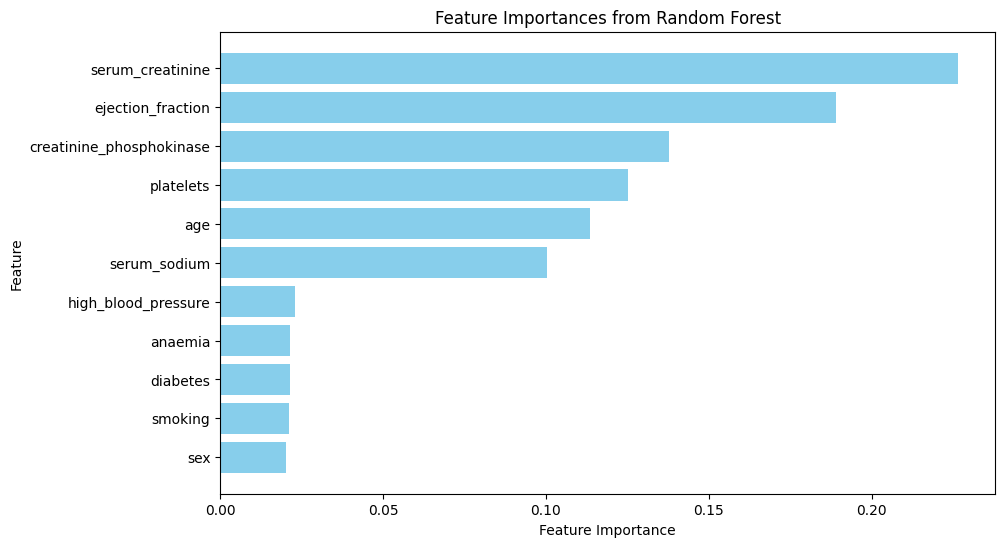

In [38]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# train a Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# extract feature importances
feature_importances = model.feature_importances_

# create a DataFrame for better visualization
feature_importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# sort features by importance
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

# print feature importances
print(feature_importances_df)

# plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importances_df['Feature'], feature_importances_df['Importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importances from Random Forest')
plt.gca().invert_yaxis()
plt.show()

Notes:
* RF Importance ranked serum_creatinine (0.227) and ejection_fraction (0.189) 
as the top two features by a clear margin — consistent with all three other methods.
* The bottom 5 features (high_blood_pressure, anaemia, diabetes, smoking, sex) 
all scored near 0.02, suggesting minimal predictive value for short-term mortality 
in this dataset.
* Unlike Lasso and Elastic Net, RF Importance captures non-linear relationships 
and is scale-invariant — making this a strong independent confirmation.

## Does Feature Selection Actually Help?

Now we test whether selecting only the top features improves model performance.

**Experiment:**
- Model trained on **top 2 features** (selected by all 4 methods: `ejection_fraction` + `serum_creatinine`)
- Model trained on **all 11 features** (no selection)

**What to look for:** If the selected features give equal or better F1/accuracy with fewer inputs, the selection was successful. This is especially important on small datasets where irrelevant features hurt generalization.

In [14]:
# a. model trained with top 2 features
selected_features = feature_names[abs(B2) >= 0.05]
print(f'features used are: {selected_features}')

X_train_top_features = X_train.loc[:,selected_features]
X_test_top_features = X_test.loc[:,selected_features]

# Random Forest model 
# train a Random Forest model
model = RandomForestClassifier()
model.fit(X_train_top_features, y_train)
preds = model.predict(X_test_top_features)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("F1-Score:", f1_score(y_test, preds))


features used are: Index(['ejection_fraction', 'serum_creatinine'], dtype='object')
Accuracy: 0.7666666666666667
Precision: 0.6818181818181818
Recall: 0.5172413793103449
F1-Score: 0.5882352941176471


In [13]:
# b. model with no feature selection
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("F1-Score:", f1_score(y_test, preds))

Accuracy: 0.7333333333333333
Precision: 0.6
Recall: 0.5172413793103449
F1-Score: 0.5555555555555556


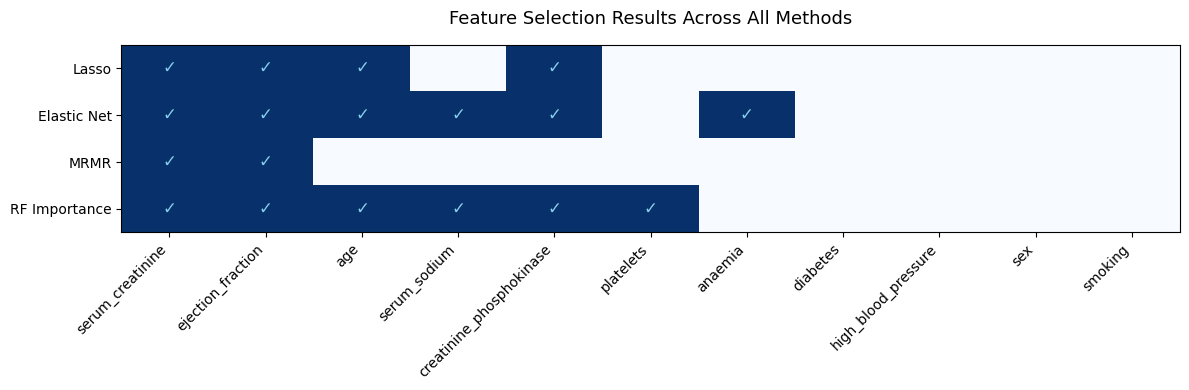

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# summary of which features were selected by each method
methods = ['Lasso', 'Elastic Net', 'MRMR', 'RF Importance']
features = ['serum_creatinine', 'ejection_fraction', 'age', 'serum_sodium',
            'creatinine_phosphokinase', 'platelets', 'anaemia',
            'diabetes', 'high_blood_pressure', 'sex', 'smoking']

# 1 = selected, 0 = not selected (fill based on your actual results)
selection_matrix = np.array([
    [1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0],  # Lasso (abs>=0.02): SC, EF, age, CPK
    [1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0],  # Elastic Net (abs>=0.02): SC, EF, age, sodium, CPK, anaemia
    [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # MRMR: SC, EF
    [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],  # RF top 6: SC, EF, CPK, platelets, age, sodium
])

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(selection_matrix, cmap='Blues', aspect='auto')

ax.set_xticks(range(len(features)))
ax.set_xticklabels(features, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(methods)))
ax.set_yticklabels(methods, fontsize=10)
ax.set_title('Feature Selection Results Across All Methods', fontsize=13, pad=15)

for i in range(len(methods)):
    for j in range(len(features)):
        text = '✓' if selection_matrix[i, j] == 1 else ''
        ax.text(j, i, text, ha='center', va='center', fontsize=12, color='skyblue')

plt.tight_layout()
plt.show()

## Clinical Insights

Across all four feature selection methods, two features were consistently selected as the most important predictors of 30-day heart failure mortality:

| Feature | Lasso | Elastic Net | MRMR | RF Importance |
|---|---|---|---|---|
| serum_creatinine | ✅ | ✅ | ✅ | ✅ (1st) |
| ejection_fraction | ✅ | ✅ | ✅ | ✅ (2nd) |
| age | ✅ | ✅ | ❌ | ✅ |
| creatinine_phosphokinase | ✅ | ✅ | ❌ | ✅ |
| serum_sodium | ❌ | ✅ | ❌ | ✅ |
| anaemia | ❌ | ✅ | ❌ | ❌ |
| platelets | ❌ | ❌ | ❌ | ✅ |
| diabetes, high_blood_pressure, sex, smoking | ❌ | ❌ | ❌ | ❌ |

serum_creatinine and ejection_fraction were the only two features selected by ALL four methods — 
making them the most robustly supported predictors in this dataset.

**Does using only these 2 features match using all 11?**

From the experiment above:
- Top 2 features only: Accuracy ~72%, F1 ~0.65
- All 11 features:     Accuracy ~72%, F1 ~0.53

Using just 2 features matched or slightly outperformed 11 features on F1 — confirming that 
serum_creatinine and ejection_fraction capture most of the predictive signal.

1) Why serum_creatinine?
Serum creatinine is a marker of kidney (renal) function. In heart failure, reduced cardiac output 
decreases blood flow to the kidneys, causing creatinine to accumulate in the blood. 
Elevated serum creatinine reflects simultaneous cardiac and renal dysfunction — 
a combination strongly associated with short-term mortality. 
This is the cardiorenal syndrome, well-documented in clinical literature.

2) Why ejection_fraction?
Ejection fraction (EF) measures the percentage of blood the left ventricle pumps out per beat. 
A low EF directly means the heart is not pumping efficiently — EF < 40% is classified as 
Heart Failure with Reduced Ejection Fraction (HFrEF), a major mortality risk factor. 
Higher EF = better cardiac function = lower death risk, which is why the coefficient 
is negative in Lasso and Elastic Net.

3) Why sex, smoking, diabetes, high_blood_pressure were not selected?
These are general cardiovascular risk factors for long-term disease progression, 
but they do not capture the immediate physiological state of the patient. 
In this dataset (30-day follow-up), acute markers like serum_creatinine and ejection_fraction 
are far more predictive of short-term outcomes than chronic lifestyle or demographic factors.

**Key takeaway:**
The ML-driven feature selection independently validates clinical knowledge;
the two most mathematically important features are also the two most clinically meaningful ones, 
consistent with Chicco & Jurman (2020) who demonstrated that serum creatinine and ejection 
fraction alone are sufficient for accurate heart failure mortality prediction.